![Palisade fire caption](/images/palisade_fire2.jpg)

In [20]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

In [ ]:
# Read in datasets
landsat = xr.open_dataset('data/landsat8-2025-02-23-palisades-eaton.nc', engine='netcdf4')

fp = os.path.join('data', 'California_Historic_Fire_Perimeters_-247493000743518952', 'California_Fire_Perimeters_(1950+).shp')
fires = gpd.read_file(fp)

fp= os.path.join('data', 'EJI_2024_United_States', 'EJI_2024_United_States.gdb')
eji = gpd.read_file(fp)

In [13]:
fires.columns = fires.columns.str.lower()
palisade = fires[(fires['fire_name'] == 'PALISADES') & (fires['year_'] == 2025)]
eaton = fires[(fires['fire_name'] == 'EATON') & (fires['year_'] == 2025)]

In [17]:
eji = eji.to_crs(crs = fires.crs)

In [18]:
# Spatial join
palisade_soc = gpd.sjoin(left_df = eji, 
                        right_df = palisade,
how = 'inner')

# Create geodf for the Eaton fire
# Spatial join
eaton_soc = gpd.sjoin(eji, eaton,
how = 'inner')

# Clip the census tracts overlapping palisades to the boundary of the fire
palisade_clip = gpd.clip(eji, palisade)

eaton_clip = gpd.clip(eji, eaton)

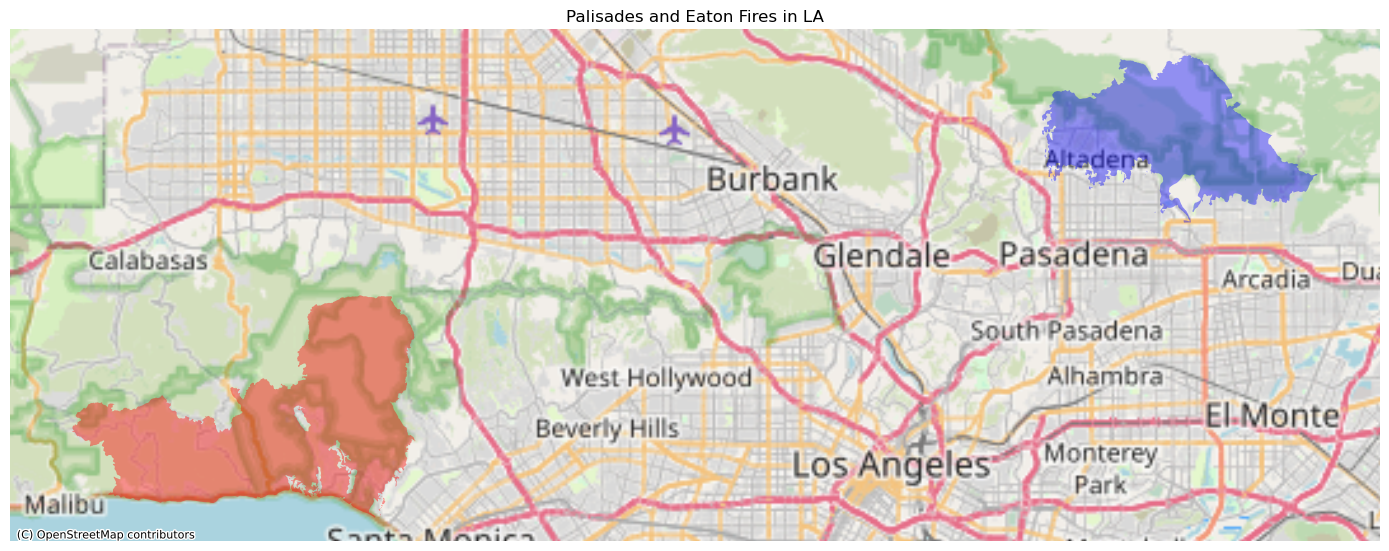

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

palisade.plot(ax=ax, color = "red", alpha = 0.4)

eaton.plot(ax=ax, color = "blue", alpha = 0.4)
# Add basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs = palisade.crs)

ax.set_title("Palisades and Eaton Fires in LA")

ax.axis('off')

plt.tight_layout()
plt.show()

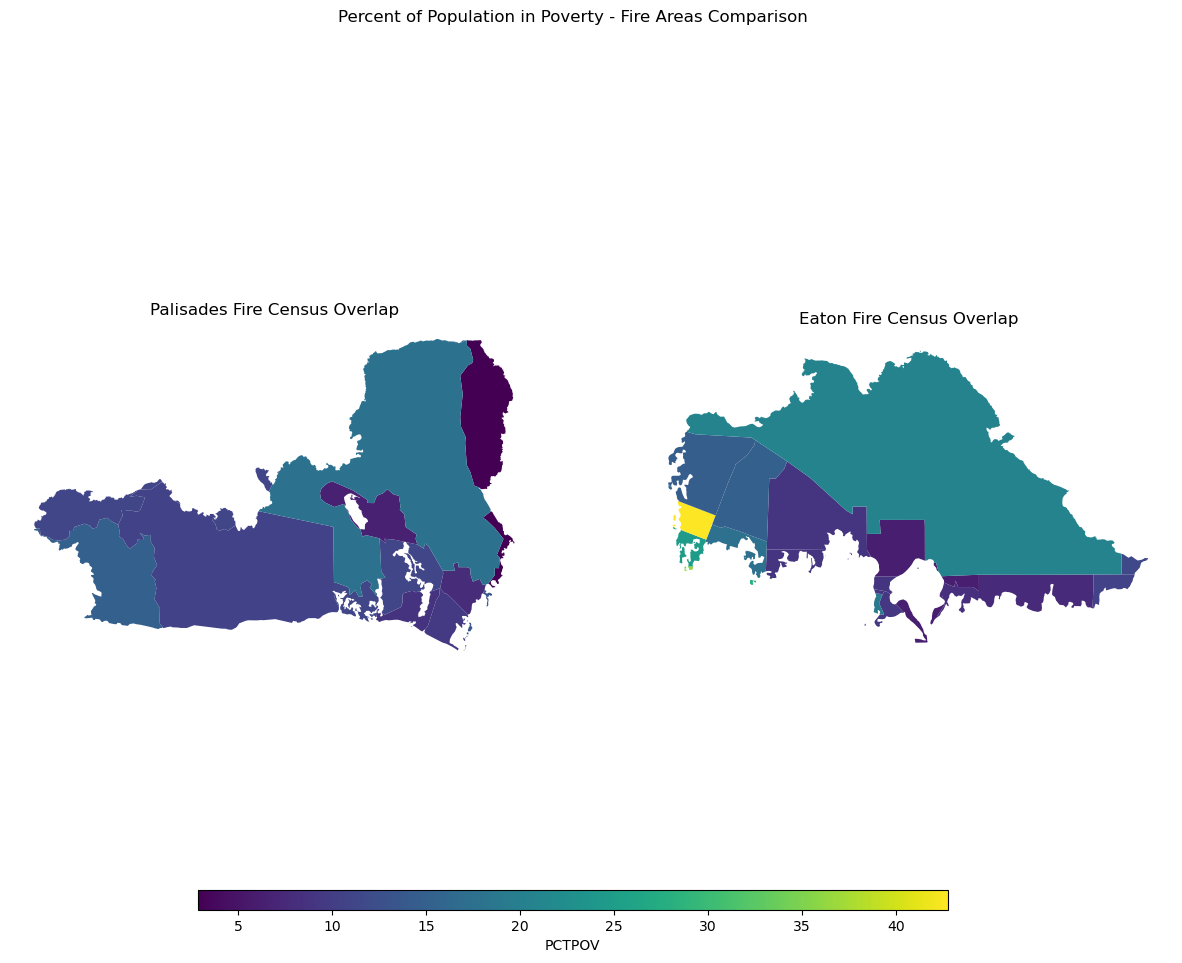

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

# UPDATE WITH YOU EJI VARIABLE FROM STEP 1
eji_variable = 'E_POV200'

# Find common min/max for legend range
vmin = min(palisade_clip[eji_variable].min(), eaton_clip[eji_variable].min())
vmax = max(palisade_clip[eji_variable].max(), eaton_clip[eji_variable].max())

# Plot census tracts within Palisades perimeter
palisade_clip.plot(
    column= eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax1,
)
ax1.set_title('Palisades Fire Census Overlap')
ax1.axis('off')

# Plot census tracts within Eaton perimeter
eaton_clip.plot(
    column=eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax2,
)
ax2.set_title('Eaton Fire Census Overlap')
ax2.axis('off')

# Add overall title
fig.suptitle('Percent of Population in Poverty - Fire Areas Comparison')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('PCTPOV')

plt.show()

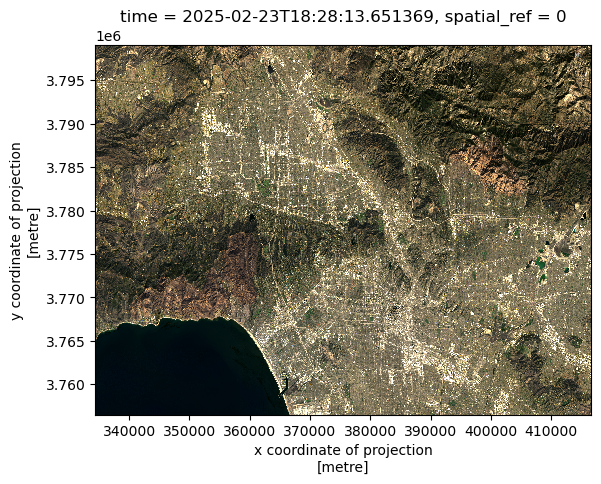

In [8]:
# Find CRS of spatial reference in landsat data itself
crs = landsat.spatial_ref.crs_wkt

# Set the crs of landsat equal to that of the spatial reference
landsat.rio.write_crs(crs, inplace= True)

# Create numpy array with true color bands 
true_col = landsat[["red", "green", "blue"]].to_array()

# Fill missing values in landsat data
landsat = landsat.fillna(0)

# Rerender plot without warnings
landsat[["red", "green", "blue"]].to_array().plot.imshow(robust = True)

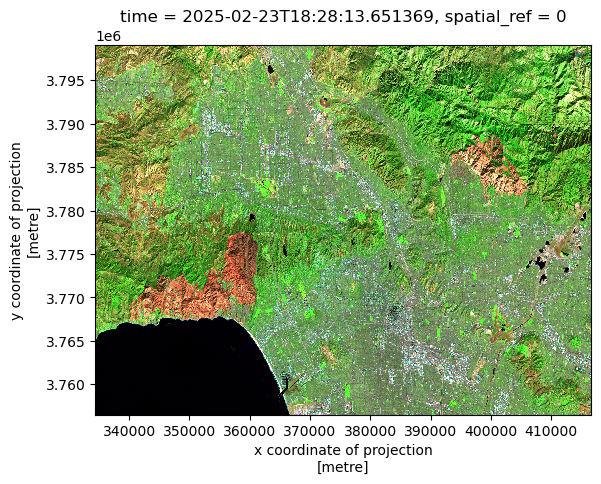

In [26]:
# Switch band order around to create false color image
plt.show(landsat[["swir22", "nir08", "red"]].to_array().plot.imshow(robust = True))

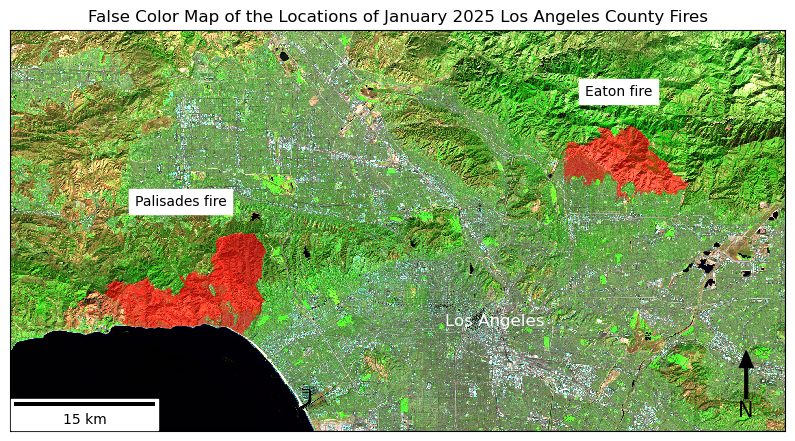

In [32]:
# Filter for Palisades fire data from 2025
palisade_perimeter = fires[(fires['fire_name'] == 'PALISADES') & (fires['year_'] == 2025)]

# Filter for Eaton fire 2025
eaton_perimeter = fires[(fires['fire_name'] == 'EATON') & (fires['year_'] == 2025)]

# Change CRS of fires data to match that of landsat data
palisade_perimeter = palisade_perimeter.to_crs(crs = 'EPSG:32611')
eaton_perimeter = eaton_perimeter.to_crs(crs = 'EPSG:32611')

# Initialize plot
fig, ax = plt.subplots(figsize = (10, 10))

# Underlay landsat false color image plot
landsat[["swir22", "nir08", "red"]].to_array().plot.imshow(ax=ax, 
                                                           robust = True)

# Add Palisade fire area onto plot
palisade_perimeter.plot(ax=ax, color = 'red', alpha = 0.5)

# Add Eaton fire area onto plot
eaton_perimeter.plot(ax=ax, color = "red", alpha = 0.5)

# Add informative title
plt.title("False Color Map of the Locations of January 2025 Los Angeles County Fires")

# Add a scalebar with matplotlib ScaleBar function
scalebar = ScaleBar(dx = 1, # Specify resolution of cell being measured
                     units = 'm', # Cells are 1m res
                     location = "lower left") # Add to lower left of plot
ax.add_artist(scalebar)

# Add compass arrow by initializing area on plot and size
x, y, arrow_length = 0.95, 0.2, 0.15

# Add annotation with text and arrow/text
ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            ha='center', va='center', fontsize=15,
            xycoords=ax.transAxes)

# Add Palisade fire annotation
fig.text(x = 0.25, 
         y = 0.52, 
         s = "Palisades fire", 
         backgroundcolor = 'white')

# Add Eaton fire annotation
fig.text(x = 0.7, 
         y = 0.63, 
         s = "Eaton fire", 
         backgroundcolor = 'white')

# Add label to downtown Los Angeles for visual context
fig.text(x = 0.56, 
         y = 0.4, 
         s = "Los Angeles", 
         color = 'white', 
         fontsize = 'large')

# Remove axes ticks
ax.set_xticks([])  
ax.set_yticks([])  

# Remove axes labels
ax.set_xlabel("")  
ax.set_ylabel("")  

plt.show()